<a href="https://colab.research.google.com/github/xquynhtrinh/STA_141C_Final_Project/blob/main/Loyalty_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load the raw transaction data (the same file you used for EDA)
df_raw = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/STA 141C/online_retail_II.xlsx",
                       sheet_name=None)  # loads both sheets as dict
df_raw = pd.concat(df_raw.values(), ignore_index=True)

# Apply the same cleaning steps as in EDA (missing Customer ID, cancellations, negative quantities/prices)
df_raw = df_raw.dropna(subset=['Customer ID'])
df_raw = df_raw[(df_raw['Quantity'] > 0) & (df_raw['Price'] > 0)]
df_raw['Total_Price'] = df_raw['Quantity'] * df_raw['Price']
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

print(f"Cleaned transaction data shape: {df_raw.shape}")

Cleaned transaction data shape: (805549, 9)


## Load RFM Segmentation Results

In [8]:
rfm_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA 141C/manual_segments_data.csv")
# Ensure Customer ID is the same type in both dataframes
rfm_df['Customer ID'] = rfm_df['Customer ID'].astype(int)
df_raw['Customer ID'] = df_raw['Customer ID'].astype(int)

# Merge to bring segment labels into transaction data
df_raw = df_raw.merge(rfm_df[['Customer ID', 'RFM_Customer_Segments']], on='Customer ID', how='left')

In [15]:
rfm_df.head()

,Customer ID,Recency,Tenure,Frequency,Monetary,Variety,AOV,InterPurchase_Time,Next_90_Days_Purchase,RFM_Customer_Segments
0,12346,235,635,12,77556.46,27,6463.038333,36.363636,0,Champions
1,12347,39,313,6,4114.18,107,685.696667,54.800000,1,Champions
2,12348,158,347,4,1709.40,25,427.350000,63.000000,1,Champions
3,12349,317,498,3,2671.14,90,890.380000,90.500000,1,Potential Loyal
4,12350,219,219,1,334.40,17,334.400000,0.000000,0,At Risk


In [12]:
df_raw.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,RFM_Customer_Segments,is_top_tier,Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,Champions,1,Seasonal
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Champions,1,Lighting
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,Champions,1,Lighting
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,Champions,1,Other
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,Champions,1,Ceramics


## Define Target Variable

Top‑Tier = Champions. Create a binary column.

In [9]:
df_raw['is_top_tier'] = (df_raw['RFM_Customer_Segments'] == 'Champions').astype(int)

## Create Product Categories

In [22]:
# Define keyword-to-category mapping
keyword_map = {
    'CHRISTMAS': 'Seasonal',
    'LIGHT': 'Lighting',
    'CANDLE': 'Candles',
    'BAG': 'Bags',
    'WRAP': 'Gift Wrap',
    'CARD': 'Cards',
    'TOY': 'Toys',
    'CERAMIC': 'Ceramics',
    'GLASS': 'Glassware',
    'WOOD': 'Wooden',
    'PAPER': 'Paper Goods',
    'RIBBON': 'Ribbons',
    'STICKER': 'Stickers',
    'MUG': 'Mugs',
    'PLATE': 'Tableware',
    'DECORATION': 'Decorations'
}

def assign_category(description):
    if pd.isna(description):
        return 'Other'
    desc_upper = str(description).upper()
    for keyword, category in keyword_map.items():
        if keyword in desc_upper:
            return category
    return 'Other'

df_raw['Category'] = df_raw['Description'].apply(assign_category)

# Check distribution
df_raw['Category'].value_counts()

,count
Category,
Other,485709
Bags,70421
Lighting,37847
Seasonal,34473
Wooden,30813
Cards,23005
Paper Goods,20330
Candles,19087
Ceramics,15727


## Aggregate Category Features per Customer

For each customer, compute:

- Spend per category (sum of Total_Price)

- Purchase count per category (number of transactions containing that category)

- Item count per category (sum of Quantity)

- Percentage of total spend coming from that category (optional)

In [23]:
# Spend per category
cat_spend = df_raw.groupby(['Customer ID', 'Category'])['Total_Price'].sum().unstack(fill_value=0)
cat_spend.columns = [f'Spend_{col}' for col in cat_spend.columns]

# Purchase count per category (count distinct invoices per category per customer)
# First, create a flag for each invoice-category combination (invoice can have multiple categories)
inv_cat = df_raw.groupby(['Customer ID', 'Invoice', 'Category']).size().reset_index(name='count')
cat_freq = inv_cat.groupby(['Customer ID', 'Category']).size().unstack(fill_value=0)
cat_freq.columns = [f'Freq_{col}' for col in cat_freq.columns]

# Merge these features
cat_features = cat_spend.merge(cat_freq, left_index=True, right_index=True, how='outer').fillna(0)

cat_features.head()

,Spend_Bags,Spend_Candles,Spend_Cards,Spend_Ceramics,Spend_Decorations,Spend_Gift Wrap,Spend_Glassware,Spend_Lighting,Spend_Mugs,Spend_Other,...,Freq_Lighting,Freq_Mugs,Freq_Other,Freq_Paper Goods,Freq_Ribbons,Freq_Seasonal,Freq_Stickers,Freq_Tableware,Freq_Toys,Freq_Wooden
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,0.0,0.0,0.0,77183.60,0.00,0.0,0.0,0.00,0.0,357.88,...,0,0,11,0,0,1,0,0,0,0
12347,607.5,129.6,568.8,0.00,9.12,21.0,0.0,518.64,0.0,3608.78,...,7,0,8,0,0,2,1,1,0,2
12348,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,1558.48,...,0,0,5,2,0,2,3,0,0,2
12349,37.2,12.6,0.0,281.52,0.00,105.0,30.2,47.30,117.0,3554.84,...,1,2,4,2,3,1,0,0,0,3
12350,20.4,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,314.00,...,0,0,1,0,0,0,0,0,0,0


## Merge with RFM Data and Prepare Final Dataset

In [24]:
# Load the RFM data (the one you used for modeling, which already has log transforms)
rfm_model_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA 141C/manual_segments_data.csv")
if 'Customer ID' in rfm_model_df.columns:
    rfm_model_df = rfm_model_df.set_index('Customer ID')

# Merge category features (which have Customer ID as index)
final_df = rfm_model_df.merge(cat_features, left_index=True, right_index=True, how='inner')

# Define target: top-tier (1 if Champion, else 0)
final_df['is_top_tier'] = (final_df['RFM_Customer_Segments'] == 'Champions').astype(int)

# Drop columns that are not features (like segment strings, etc.)
X = final_df.drop(['is_top_tier', 'RFM_Customer_Segments', 'RFM_Segment_Label'], axis=1, errors='ignore')
y = final_df['is_top_tier']

## Train/Test Split & Modeling

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Use class_weight='balanced' because Champions are a minority
rf = RandomForestClassifier(n_estimators=200, max_depth=7, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate (optional)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       672
           1       0.98      0.97      0.97       384

    accuracy                           0.98      1056
   macro avg       0.98      0.98      0.98      1056
weighted avg       0.98      0.98      0.98      1056

ROC-AUC: 0.998


## Feature Importances Analysis

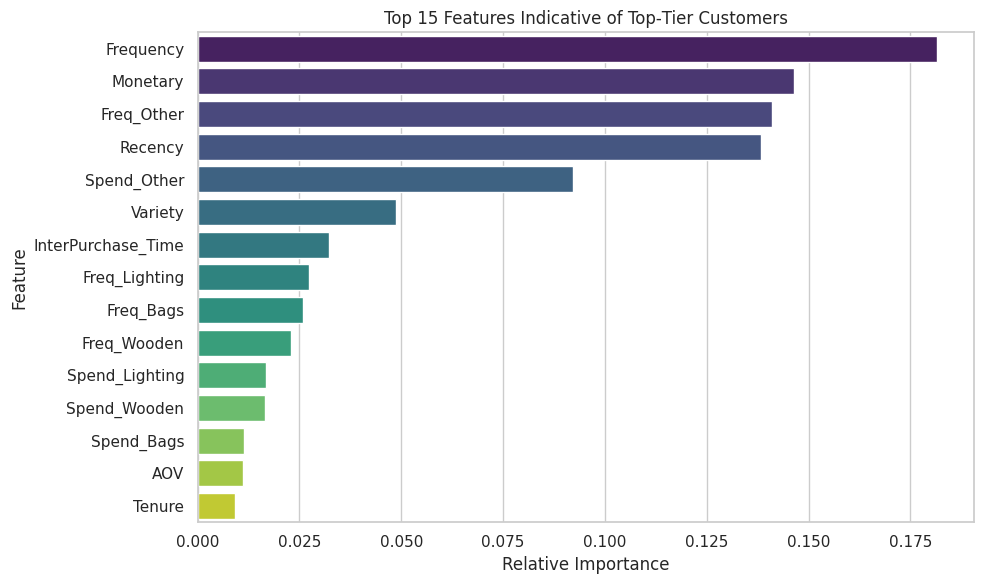

In [26]:
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 15 Features Indicative of Top‑Tier Customers')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

Bulleted Insights:

- Frequency, Monetary, and Recency dominate – Champions buy often, spend more, and shop recently.

- "Other" category is surprisingly important – suggests Champions buy a wide variety of miscellaneous items; investigate what's in "Other".

- Specific product signals: Bags, Lighting, and Wooden items appear more frequently among Champions.

- AOV and Tenure are weak predictors – it's not about order size or loyalty duration, but consistent engagement.

Business Actions:

- Double‑down on basics: Use RFM metrics to identify potential Champions early.

- Analyze the "Other" category: Find hidden gems that resonate with top customers.

- Promote key categories: Feature Bags, Lighting, and Wooden products in campaigns targeting high‑value customers.

- Don't over‑invest in tenure‑based loyalty: New customers with strong engagement can become Champions quickly – nurture them.